# Residual-Based Root Cause Analysis
Goal: identify which sensors contribute most during anomalous transitions.

Approach:

• compute linear model residuals  
• decompose residual energy per sensor  
• rank sensors by contribution  
• analyze which sensors repeatedly trigger anomalies

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

## Load Continuous Normalized Data and Linear Model

We use:
- Continuous test sequence
- Linear transition matrix A (from Step 5)

These must already be saved.

In [2]:
X_test = np.load("data/X_test_raw.npy")
A = np.load("data/linear_A.npy")   # make sure you saved A in Step 5

print("Test shape:", X_test.shape)
print("A shape:", A.shape)

Test shape: (415, 12)
A shape: (12, 12)


## Per-Sensor Residual Contributions

Instead of only computing total residual energy,

energy = Σ r_i²

we compute the squared residual for each sensor.

This allows us to attribute anomalies to individual channels.

In [3]:
def compute_sensor_residuals(sequence, A):
    residuals = []
    
    for t in range(len(sequence) - 1):
        x_pred = sequence[t] @ A
        r = sequence[t+1] - x_pred
        
        # Per-sensor squared residual
        residuals.append(r**2)
    
    return np.array(residuals)

In [4]:
sensor_residuals = compute_sensor_residuals(X_test, A)

print("Sensor residuals shape:", sensor_residuals.shape)

Sensor residuals shape: (414, 12)


## Total Residual Energy

The sum of squared residuals is used as the anomaly score.

In [5]:
test_residuals = np.sum(sensor_residuals, axis=1)

print("Residual energy shape:", test_residuals.shape)

Residual energy shape: (414,)


## Threshold Estimation

Threshold is estimated from validation residuals.

In [6]:
X_val = np.load("data/X_val_raw.npy")

val_sensor_residuals = compute_sensor_residuals(X_val, A)
val_residuals = np.sum(val_sensor_residuals, axis=1)

threshold = np.percentile(val_residuals, 95)

print("Residual threshold:", threshold)

Residual threshold: 45.19562497771508


## Detect Anomalous Transitions

In [7]:
anomaly_indices = np.where(test_residuals > threshold)[0]

print("Number of anomalies:", len(anomaly_indices))

Number of anomalies: 23


## Example: Root Cause for First Detected Anomaly

In [8]:
if len(anomaly_indices) > 0:
    idx = anomaly_indices[0]
    
    contributions = sensor_residuals[idx]
    ranked = np.argsort(contributions)[::-1]
    
    print("Top 5 contributing sensors:")
    for i in range(5):
        print(f"Sensor {ranked[i]} — Contribution: {contributions[ranked[i]]:.6f}")

Top 5 contributing sensors:
Sensor 7 — Contribution: 84.274842
Sensor 6 — Contribution: 5.919212
Sensor 11 — Contribution: 2.979196
Sensor 10 — Contribution: 2.597926
Sensor 0 — Contribution: 0.190008


## Visualize Sensor Contributions (Single Event)

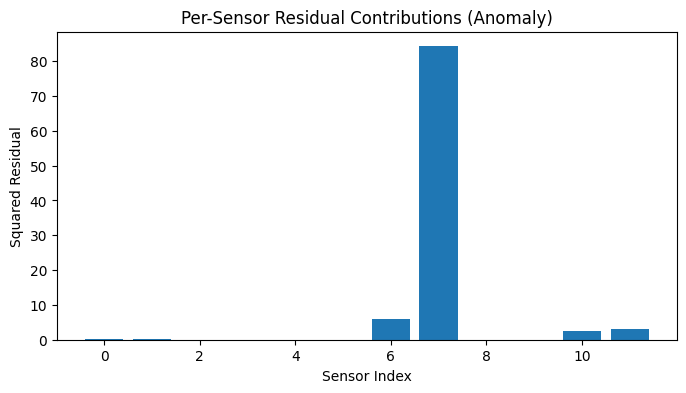

In [9]:
plt.figure(figsize=(8,4))
plt.bar(range(len(contributions)), contributions)
plt.title("Per-Sensor Residual Contributions (Anomaly)")
plt.xlabel("Sensor Index")
plt.ylabel("Squared Residual")
plt.show()

## Root Cause Frequency Across All Anomalies

Which sensor most frequently initiates anomalies?

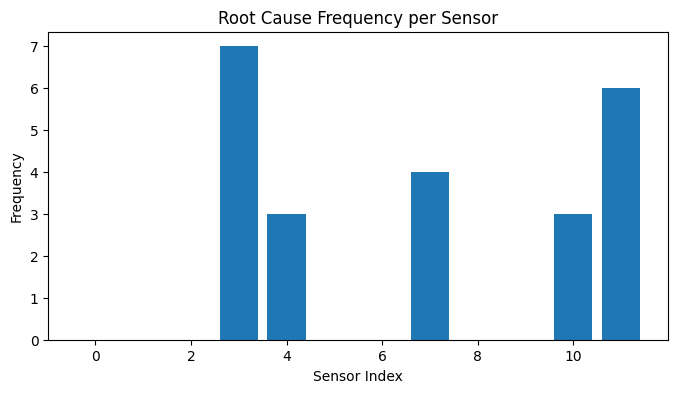

In [10]:
root_cause_counts = np.zeros(sensor_residuals.shape[1])

for idx in anomaly_indices:
    contributions = sensor_residuals[idx]
    root_sensor = np.argmax(contributions)
    root_cause_counts[root_sensor] += 1

plt.figure(figsize=(8,4))
plt.bar(range(len(root_cause_counts)), root_cause_counts)
plt.title("Root Cause Frequency per Sensor")
plt.xlabel("Sensor Index")
plt.ylabel("Frequency")
plt.show()

## Observations

Residual energy can be decomposed into contributions from each sensor.

During anomalous transitions, a small number of sensors typically
dominate the residual energy.

This allows anomalies to be traced back to specific telemetry channels,
providing interpretable fault localization rather than a black-box signal.

## Summary

The linear dynamical model provides both anomaly detection
and interpretable attribution.

While the LSTM captures complex temporal patterns,
the linear residual model offers a clear explanation
of which sensors drive anomalous transitions.